# Notebook 164: GPTスタイルの自己回帰言語モデル

**難易度**: ★★★★☆ | **推定時間**: 120-150分 | **カテゴリ**: 言語モデル

**前提知識**: Notebook 162 (NLP Transformer), 163 (BERT事前学習)

---

## 学習目標

このノートブックを完了すると、以下ができるようになります：

- [ ] Causal Language Modeling (CLM) 目的関数の数理を理解できる
- [ ] ミニGPTをスクラッチ実装できる（Decoder-only Transformer）
- [ ] next-token prediction の訓練ループを構築できる
- [ ] Teacher Forcing と Autoregressive Generation の違いを説明できる
- [ ] 小規模テキストデータで文章生成を実行できる
- [ ] Attention重みの可視化から言語モデルの振る舞いを分析できる

---
## 1. 環境セットアップ

必要なライブラリをインポートし、再現性のためにシードを固定します。

In [1]:
# ============================================================
# セクション1: 環境セットアップ
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import copy
from collections import Counter

# ------------------------------------------------------------
# 再現性のためのシード固定
# ------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

# ------------------------------------------------------------
# 日本語フォント設定（matplotlib）
# ------------------------------------------------------------
try:
    import matplotlib
    matplotlib.rcParams['font.family'] = 'Hiragino Sans'
except Exception:
    pass  # 日本語フォントが無い環境ではデフォルトフォントを使用

# ------------------------------------------------------------
# 描画スタイル設定
# ------------------------------------------------------------
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
sns.set_style('whitegrid')

# ------------------------------------------------------------
# デバイス設定
# ------------------------------------------------------------
device = torch.device('cpu')  # CPU上で動作
print(f'PyTorch version: {torch.__version__}')
print(f'Device: {device}')

C:\Users\yuzup\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


PyTorch version: 2.1.2+cpu
Device: cpu


---
## 2. BERTからGPTへ — 双方向 vs 自己回帰

### 2.1 Encoder-only (BERT) vs Decoder-only (GPT)

Transformerアーキテクチャには大きく2つの流派があります：

| 特徴 | BERT (Encoder-only) | GPT (Decoder-only) |
|------|---------------------|---------------------|
| **マスク** | 双方向（全トークンが見える） | 因果的（左側のみ見える） |
| **事前学習** | Masked LM (MLM) | Causal LM (CLM) |
| **得意タスク** | 分類、NER、QA | 文章生成、対話 |
| **文脈** | 前後の文脈を使用 | 左側の文脈のみ使用 |

### 2.2 Causal Language Modeling (CLM)

GPTは**自己回帰（autoregressive）**な言語モデルです。

数式で表すと、テキスト列 $w_1, w_2, \ldots, w_T$ の同時確率を条件付き確率の積に分解します：

$$P(w_1, w_2, \ldots, w_T) = \prod_{t=1}^{T} P(w_t \mid w_1, w_2, \ldots, w_{t-1})$$

訓練時の**目的関数**は、この対数尤度を最大化すること：

$$\mathcal{L} = -\frac{1}{T}\sum_{t=1}^{T} \log P(w_t \mid w_1, \ldots, w_{t-1}; \theta)$$

これは各ステップで**次のトークンを予測する交差エントロピー損失**と等価です。

C:\Users\yuzup\anaconda3\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\yuzup\anaconda3\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 29031 (\N{CJK UNIFIED IDEOGRAPH-7167}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\yuzup\anaconda3\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 20808 (\N{CJK UNIFIED IDEOGRAPH-5148}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\yuzup\anaconda3\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 29694 (\N{CJK UNIFIED IDEOGRAPH-73FE}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\yuzup\anaconda3\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\yuzup\anaconda3\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) Arial.
  fig.ca

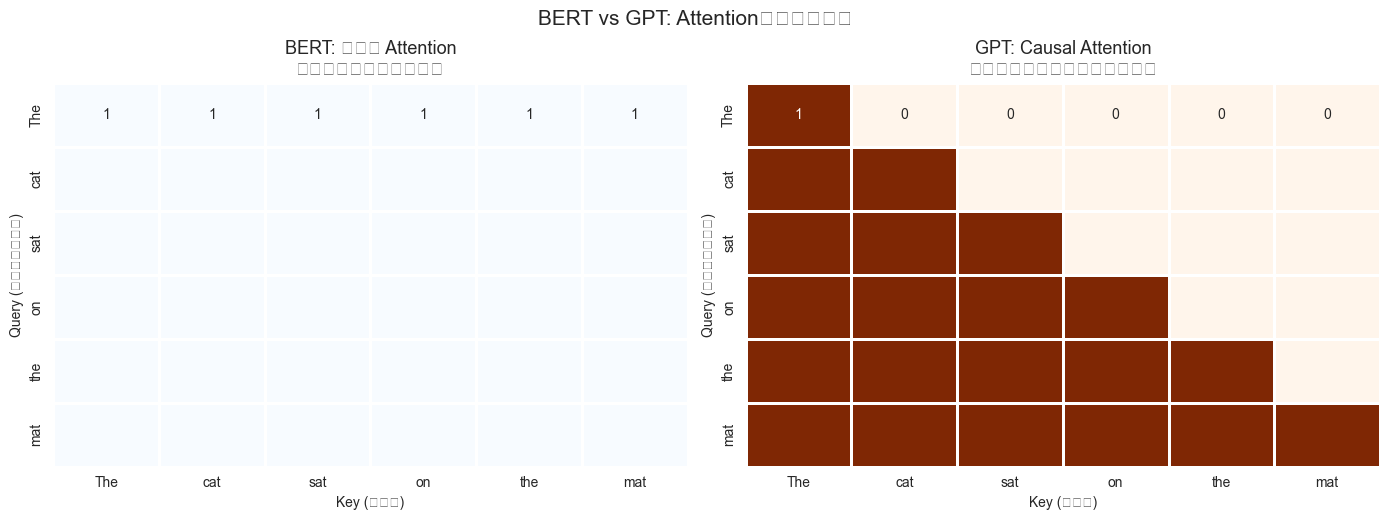

【解説】
BERT: 各トークンが文全体のコンテキストを参照できる（双方向）
GPT:  各トークンは自分より前のトークンのみ参照できる（因果的）
      → これにより「次のトークンを予測する」タスクが成立する


In [2]:
# ============================================================
# セクション2: Causal Maskと情報の流れの図解
# ============================================================

# ------------------------------------------------------------
# BERTとGPTのAttentionパターンの比較図
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seq_len = 6
tokens = ['The', 'cat', 'sat', 'on', 'the', 'mat']

# --- BERT: 双方向 Attention ---
# BERTでは全トークンが全トークンを見られる
bert_mask = np.ones((seq_len, seq_len))
sns.heatmap(bert_mask, ax=axes[0], cmap='Blues', cbar=False,
            xticklabels=tokens, yticklabels=tokens,
            linewidths=1, linecolor='white',
            annot=True, fmt='.0f')
axes[0].set_title('BERT: 双方向 Attention\n（全トークンが見える）', fontsize=13)
axes[0].set_xlabel('Key (参照先)')
axes[0].set_ylabel('Query (現在のトークン)')

# --- GPT: Causal Attention ---
# GPTでは各トークンは自分より左のトークンのみ見られる
gpt_mask = np.tril(np.ones((seq_len, seq_len)))
sns.heatmap(gpt_mask, ax=axes[1], cmap='Oranges', cbar=False,
            xticklabels=tokens, yticklabels=tokens,
            linewidths=1, linecolor='white',
            annot=True, fmt='.0f')
axes[1].set_title('GPT: Causal Attention\n（左側のトークンのみ見える）', fontsize=13)
axes[1].set_xlabel('Key (参照先)')
axes[1].set_ylabel('Query (現在のトークン)')

plt.tight_layout()
plt.suptitle('BERT vs GPT: Attentionマスクの比較', fontsize=15, y=1.03)
plt.show()

print('【解説】')
print('BERT: 各トークンが文全体のコンテキストを参照できる（双方向）')
print('GPT:  各トークンは自分より前のトークンのみ参照できる（因果的）')
print('      → これにより「次のトークンを予測する」タスクが成立する')

---
## 3. Causal Maskの実装

GPTの核となるのは**Causal Mask（因果マスク）**です。
これにより、各位置のトークンは未来の情報にアクセスできなくなります。

In [3]:
# ============================================================
# セクション3: Causal Maskの実装と可視化
# ============================================================

def create_causal_mask(seq_len):
    """
    Causal Mask（因果マスク）を生成する。
    
    下三角行列を作成し、未来のトークンへのAttentionを防ぐ。
    マスクされた位置は -inf になり、softmax後にゼロになる。
    
    Args:
        seq_len: シーケンス長
    Returns:
        mask: (seq_len, seq_len) のマスクテンソル
              見てよい位置 = 0, 見てはいけない位置 = -inf
    """
    # 上三角部分を -inf で埋める（対角線を含まない）
    mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1)
    mask = mask.masked_fill(mask == 1, float('-inf'))
    return mask

# ------------------------------------------------------------
# マスクの動作確認
# ------------------------------------------------------------
print('=== Causal Mask (seq_len=6) ===')
mask = create_causal_mask(6)
print(mask)
print()
print('0 = 参照可能、-inf = 参照不可')

=== Causal Mask (seq_len=6) ===
tensor([[0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0.]])

0 = 参照可能、-inf = 参照不可


C:\Users\yuzup\anaconda3\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\yuzup\anaconda3\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\yuzup\anaconda3\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\yuzup\anaconda3\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\yuzup\AppData\Local\Temp\ipykernel_24828\802440471.py:21: UserWarning: Glyph 12497 (\N{KATAKANA LETTER PA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yuzup\AppData\Local\Temp\ipykernel_24828\802440471.py:21: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) Arial.
  plt.tig

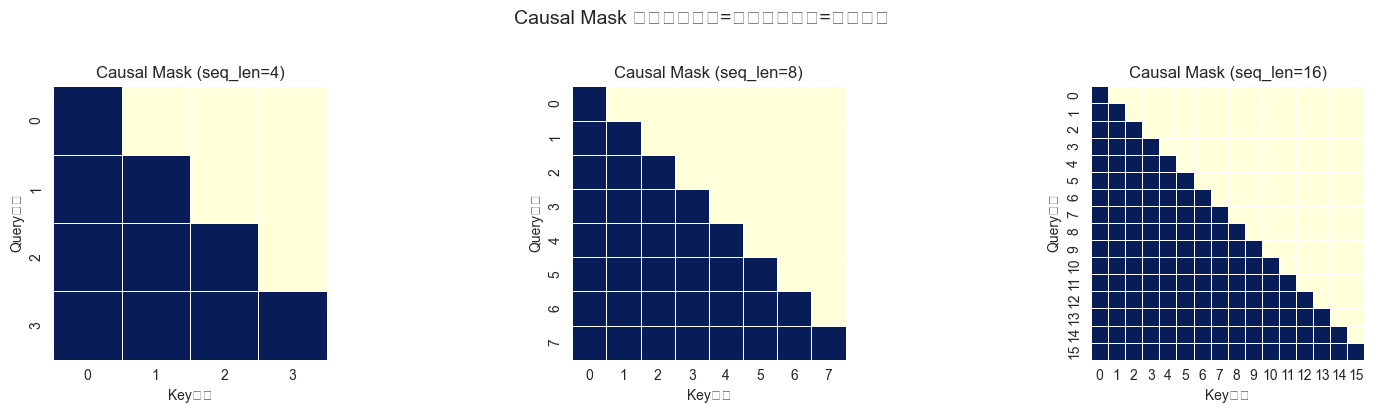

各位置のトークンは、自分自身と左側のトークンのみ参照できます。
右上の三角形がマスクされ、未来の情報が遮断されます。


In [4]:
# ============================================================
# Causal Maskパターンのヒートマップ可視化
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 異なるシーケンス長でのマスクを可視化
for idx, sl in enumerate([4, 8, 16]):
    m = create_causal_mask(sl)
    # 可視化用に変換: 参照可能=1, 不可=-inf→0
    vis = (m == 0).float().numpy()
    sns.heatmap(vis, ax=axes[idx], cmap='YlGnBu',
                cbar=False, linewidths=0.5,
                square=True)
    axes[idx].set_title(f'Causal Mask (seq_len={sl})', fontsize=12)
    axes[idx].set_xlabel('Key位置')
    axes[idx].set_ylabel('Query位置')

plt.suptitle('Causal Mask パターン（青=参照可能、白=マスク）',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('各位置のトークンは、自分自身と左側のトークンのみ参照できます。')
print('右上の三角形がマスクされ、未来の情報が遮断されます。')

In [5]:
# ============================================================
# マスク付きAttentionの動作確認
# ============================================================

def masked_attention_demo(seq_len=5, d_k=4):
    """
    Causal Maskを適用したAttentionの動作デモ。
    マスクにより未来のトークンへの重みがゼロになることを確認する。
    """
    torch.manual_seed(42)
    
    # ダミーのQuery, Key, Valueを生成
    Q = torch.randn(1, seq_len, d_k)
    K = torch.randn(1, seq_len, d_k)
    V = torch.randn(1, seq_len, d_k)
    
    # Attentionスコアを計算
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    print('=== マスク適用前のAttentionスコア ===')
    print(scores.squeeze().detach().numpy().round(2))
    
    # Causal Maskを適用
    mask = create_causal_mask(seq_len)
    scores_masked = scores + mask
    print('\n=== マスク適用後のAttentionスコア ===')
    print(scores_masked.squeeze().detach().numpy().round(2))
    
    # Softmaxで正規化
    attn_weights = F.softmax(scores_masked, dim=-1)
    print('\n=== Attention重み（softmax後） ===')
    print(attn_weights.squeeze().detach().numpy().round(3))
    print()
    print('→ 上三角部分（未来のトークン）の重みが 0.000 になっています！')
    
    return attn_weights.squeeze().detach().numpy()

attn = masked_attention_demo()

=== マスク適用前のAttentionスコア ===
[[ 0.94 -0.85  1.58 -1.68  2.16]
 [-0.88  0.68  0.14  0.86 -0.97]
 [ 0.03 -0.26 -0.39 -0.13  0.03]
 [-0.42 -0.08 -0.4   0.52 -0.4 ]
 [ 0.4   0.99  0.6  -0.55 -0.24]]

=== マスク適用後のAttentionスコア ===
[[ 0.94  -inf  -inf  -inf  -inf]
 [-0.88  0.68  -inf  -inf  -inf]
 [ 0.03 -0.26 -0.39  -inf  -inf]
 [-0.42 -0.08 -0.4   0.52  -inf]
 [ 0.4   0.99  0.6  -0.55 -0.24]]

=== Attention重み（softmax後） ===
[[1.    0.    0.    0.    0.   ]
 [0.174 0.826 0.    0.    0.   ]
 [0.417 0.311 0.273 0.    0.   ]
 [0.168 0.235 0.17  0.428 0.   ]
 [0.202 0.365 0.248 0.078 0.107]]

→ 上三角部分（未来のトークン）の重みが 0.000 になっています！


---
## 4. データの準備

ミニGPTを訓練するための小規模テキストコーパスを用意します。
シンプルな英語の文を使い、**文字レベル**でトークン化します。

In [6]:
# ============================================================
# セクション4: データの準備
# ============================================================

# ------------------------------------------------------------
# 小規模テキストコーパス（シンプルな英語文）
# 童話風・簡単な文を使用
# ------------------------------------------------------------
corpus = """
once upon a time there was a little cat.
the cat liked to play in the garden.
every day the cat would chase butterflies.
one day the cat found a small bird.
the bird was sitting on a tree branch.
the cat watched the bird carefully.
the bird sang a beautiful song.
the cat listened to the song happily.
then the cat went home for dinner.
the cat ate fish and drank milk.
after dinner the cat fell asleep.
the cat dreamed about the bird.
in the dream they became good friends.
the next morning the cat woke up early.
the cat ran to the garden again.
the bird was there waiting for the cat.
they played together all day long.
the cat and the bird were happy.
when the sun went down they said goodbye.
the cat went home and slept well.
once upon a time there was a kind dog.
the dog liked to help other animals.
one day the dog met a lost rabbit.
the dog helped the rabbit find its home.
the rabbit was very thankful to the dog.
the dog and the rabbit became friends.
they shared food and played games.
every evening they watched the sunset.
the dog was happy to have a friend.
and they lived happily ever after.
""".strip()

print(f'コーパスの文字数: {len(corpus)}')
print(f'先頭100文字: {corpus[:100]}...')

コーパスの文字数: 1108
先頭100文字: once upon a time there was a little cat.
the cat liked to play in the garden.
every day the cat woul...


In [7]:
# ============================================================
# 文字レベルのトークン化
# ============================================================

# ------------------------------------------------------------
# ユニークな文字を抽出して語彙を構築
# ------------------------------------------------------------
chars = sorted(list(set(corpus)))
vocab_size = len(chars)

# 文字→インデックス、インデックス→文字のマッピング
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

print(f'語彙サイズ（ユニーク文字数）: {vocab_size}')
print(f'語彙: {chars}')
print()

# ------------------------------------------------------------
# テキスト全体をインデックス列に変換
# ------------------------------------------------------------
data = torch.tensor([char_to_idx[ch] for ch in corpus], dtype=torch.long)
print(f'データの形状: {data.shape}')
print(f'先頭20トークン: {data[:20].tolist()}')
print(f'対応する文字:   {[idx_to_char[i] for i in data[:20].tolist()]}')

語彙サイズ（ユニーク文字数）: 26
語彙: ['\n', ' ', '.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y']

データの形状: torch.Size([1108])
先頭20トークン: [16, 15, 5, 7, 1, 21, 17, 16, 15, 1, 3, 1, 20, 11, 14, 7, 1, 20, 10, 7]
対応する文字:   ['o', 'n', 'c', 'e', ' ', 'u', 'p', 'o', 'n', ' ', 'a', ' ', 't', 'i', 'm', 'e', ' ', 't', 'h', 'e']


In [8]:
# ============================================================
# スライディングウィンドウでの入力/ターゲットペア作成
# ============================================================

class TextDataset(Dataset):
    """
    自己回帰言語モデル用データセット。
    
    スライディングウィンドウ方式で入力/ターゲットのペアを作成。
    入力:   [w_1, w_2, ..., w_{T-1}]
    ターゲット: [w_2, w_3, ..., w_T]
    → 各位置で「次のトークン」を予測する。
    """
    
    def __init__(self, data, seq_len):
        """
        Args:
            data: トークンインデックスのテンソル
            seq_len: シーケンス長（コンテキストウィンドウサイズ）
        """
        self.data = data
        self.seq_len = seq_len
    
    def __len__(self):
        # スライディングウィンドウの数
        return len(self.data) - self.seq_len
    
    def __getitem__(self, idx):
        # 入力: 位置 idx から seq_len 個のトークン
        x = self.data[idx:idx + self.seq_len]
        # ターゲット: 入力を1つずらしたもの（次のトークン）
        y = self.data[idx + 1:idx + self.seq_len + 1]
        return x, y

# ------------------------------------------------------------
# データセットとDataLoaderの構築
# ------------------------------------------------------------
SEQ_LEN = 64  # コンテキストウィンドウサイズ
BATCH_SIZE = 32

dataset = TextDataset(data, SEQ_LEN)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f'シーケンス長: {SEQ_LEN}')
print(f'バッチサイズ: {BATCH_SIZE}')
print(f'データセットのサンプル数: {len(dataset)}')
print(f'バッチ数: {len(dataloader)}')
print()

# サンプルを1つ取得して確認
sample_x, sample_y = dataset[0]
print('=== サンプル（最初のウィンドウ） ===')
print(f'入力 x:     {sample_x[:20].tolist()}')
print(f'ターゲット y: {sample_y[:20].tolist()}')
print(f'入力テキスト:   {"|".join([idx_to_char[i] for i in sample_x[:20].tolist()])}')
print(f'ターゲットテキスト: {"|".join([idx_to_char[i] for i in sample_y[:20].tolist()])}')
print()
print('→ 入力の各位置に対して、1つ右にずれたトークンがターゲットです。')

シーケンス長: 64
バッチサイズ: 32
データセットのサンプル数: 1044
バッチ数: 33

=== サンプル（最初のウィンドウ） ===
入力 x:     [16, 15, 5, 7, 1, 21, 17, 16, 15, 1, 3, 1, 20, 11, 14, 7, 1, 20, 10, 7]
ターゲット y: [15, 5, 7, 1, 21, 17, 16, 15, 1, 3, 1, 20, 11, 14, 7, 1, 20, 10, 7, 18]
入力テキスト:   o|n|c|e| |u|p|o|n| |a| |t|i|m|e| |t|h|e
ターゲットテキスト: n|c|e| |u|p|o|n| |a| |t|i|m|e| |t|h|e|r

→ 入力の各位置に対して、1つ右にずれたトークンがターゲットです。


---
## 5. ミニGPTのスクラッチ実装

Decoder-only Transformerを一から実装します。

### アーキテクチャ概要

```
入力トークン列
    ↓
トークン埋め込み + 位置埋め込み
    ↓
┌──────────────────────────┐
│  Transformer Decoder Block × N  │
│  ┌──────────────────────┐│
│  │ Masked Multi-Head     ││
│  │ Self-Attention        ││
│  ├──────────────────────┤│
│  │ Add & LayerNorm      ││
│  ├──────────────────────┤│
│  │ Feed-Forward Network  ││
│  ├──────────────────────┤│
│  │ Add & LayerNorm      ││
│  └──────────────────────┘│
└──────────────────────────┘
    ↓
線形射影 → 語彙サイズ
    ↓
next-token 確率分布
```

In [9]:
# ============================================================
# セクション5: ミニGPTのスクラッチ実装
# ============================================================

# ------------------------------------------------------------
# 設定クラス
# ------------------------------------------------------------
class GPTConfig:
    """
    ミニGPTモデルの設定パラメータ。
    小規模な実験用に設計されている。
    """
    vocab_size: int = vocab_size   # 語彙サイズ（文字数）
    d_model: int = 128             # 埋め込み次元
    n_heads: int = 4               # Attentionヘッド数
    n_layers: int = 4              # Transformerブロック数
    max_seq_len: int = 64          # 最大シーケンス長
    d_ff: int = 256                # FFN中間層の次元
    dropout: float = 0.1           # ドロップアウト率

config = GPTConfig()
print('=== GPT設定 ===')
for attr in ['vocab_size', 'd_model', 'n_heads', 'n_layers',
             'max_seq_len', 'd_ff', 'dropout']:
    print(f'  {attr}: {getattr(config, attr)}')

=== GPT設定 ===
  vocab_size: 26
  d_model: 128
  n_heads: 4
  n_layers: 4
  max_seq_len: 64
  d_ff: 256
  dropout: 0.1


In [10]:
# ============================================================
# Multi-Head Self-Attention（マスク付き）
# ============================================================

class CausalSelfAttention(nn.Module):
    """
    Causal（因果的）Self-Attention。
    
    未来のトークンを参照できないようにマスクを適用。
    GPTの中核となるモジュール。
    """
    
    def __init__(self, config):
        super().__init__()
        assert config.d_model % config.n_heads == 0, \
            'd_model は n_heads で割り切れる必要があります'
        
        self.n_heads = config.n_heads
        self.d_k = config.d_model // config.n_heads
        
        # Query, Key, Value の線形変換（一括計算）
        self.qkv_proj = nn.Linear(config.d_model, 3 * config.d_model)
        # 出力の線形変換
        self.out_proj = nn.Linear(config.d_model, config.d_model)
        self.dropout = nn.Dropout(config.dropout)
        
        # Causal Maskを事前に登録（バッファとして保持）
        mask = torch.triu(torch.ones(config.max_seq_len, config.max_seq_len),
                          diagonal=1).bool()
        self.register_buffer('mask', mask)
        
        # Attention重みを保存（可視化用）
        self.attn_weights = None
    
    def forward(self, x):
        """
        Args:
            x: (batch, seq_len, d_model)
        Returns:
            output: (batch, seq_len, d_model)
        """
        B, T, C = x.shape
        
        # Q, K, V を一括計算して分割
        qkv = self.qkv_proj(x)  # (B, T, 3*d_model)
        q, k, v = qkv.chunk(3, dim=-1)  # 各 (B, T, d_model)
        
        # マルチヘッドに分割: (B, T, d_model) → (B, n_heads, T, d_k)
        q = q.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        
        # Attentionスコア: (B, n_heads, T, T)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        # Causal Maskの適用: 未来の位置を -inf に
        scores = scores.masked_fill(self.mask[:T, :T].unsqueeze(0).unsqueeze(0),
                                    float('-inf'))
        
        # Softmaxで正規化
        attn = F.softmax(scores, dim=-1)
        self.attn_weights = attn.detach()  # 可視化用に保存
        attn = self.dropout(attn)
        
        # Value との加重和: (B, n_heads, T, d_k)
        out = torch.matmul(attn, v)
        
        # ヘッドを結合: (B, T, d_model)
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        
        # 出力射影
        out = self.out_proj(out)
        return out

In [11]:
# ============================================================
# Transformer Decoder Block
# ============================================================

class TransformerDecoderBlock(nn.Module):
    """
    GPTの1つのDecoderブロック。
    
    構成:
        Masked Multi-Head Self-Attention → Add & LayerNorm
        → Feed-Forward Network → Add & LayerNorm
    
    Pre-LayerNorm（GPT-2スタイル）を採用。
    """
    
    def __init__(self, config):
        super().__init__()
        # Layer Normalization
        self.ln1 = nn.LayerNorm(config.d_model)
        self.ln2 = nn.LayerNorm(config.d_model)
        
        # Masked Self-Attention
        self.attn = CausalSelfAttention(config)
        
        # Feed-Forward Network (FFN)
        self.ffn = nn.Sequential(
            nn.Linear(config.d_model, config.d_ff),
            nn.GELU(),  # GPT-2ではGELUを使用
            nn.Linear(config.d_ff, config.d_model),
            nn.Dropout(config.dropout)
        )
    
    def forward(self, x):
        """
        Pre-LayerNorm + 残差接続
        
        Args:
            x: (batch, seq_len, d_model)
        Returns:
            (batch, seq_len, d_model)
        """
        # Masked Self-Attention + 残差接続
        x = x + self.attn(self.ln1(x))
        # FFN + 残差接続
        x = x + self.ffn(self.ln2(x))
        return x

In [12]:
# ============================================================
# ミニGPTモデル本体
# ============================================================

class MiniGPT(nn.Module):
    """
    ミニGPT: Decoder-only Transformerによる自己回帰言語モデル。
    
    構成:
        1. トークン埋め込み (Token Embedding)
        2. 位置埋め込み (Positional Embedding)
        3. Transformer Decoder Blocks × N
        4. 最終Layer Norm
        5. 出力ヘッド（語彙サイズへの線形射影）
    """
    
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        # --- トークン埋め込み ---
        self.token_emb = nn.Embedding(config.vocab_size, config.d_model)
        
        # --- 位置埋め込み（学習可能） ---
        self.pos_emb = nn.Embedding(config.max_seq_len, config.d_model)
        
        # --- ドロップアウト ---
        self.dropout = nn.Dropout(config.dropout)
        
        # --- Transformer Decoder Blocks ---
        self.blocks = nn.ModuleList([
            TransformerDecoderBlock(config) for _ in range(config.n_layers)
        ])
        
        # --- 最終Layer Norm ---
        self.ln_f = nn.LayerNorm(config.d_model)
        
        # --- 出力ヘッド: d_model → vocab_size ---
        self.head = nn.Linear(config.d_model, config.vocab_size, bias=False)
        
        # 重み初期化
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        """Xavier/Kaiming初期化"""
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
    
    def forward(self, idx):
        """
        Args:
            idx: (batch, seq_len) トークンインデックスのテンソル
        Returns:
            logits: (batch, seq_len, vocab_size) 各位置での次トークン予測
        """
        B, T = idx.shape
        assert T <= self.config.max_seq_len, \
            f'シーケンス長 {T} が最大長 {self.config.max_seq_len} を超えています'
        
        # トークン埋め込み + 位置埋め込み
        tok_emb = self.token_emb(idx)                      # (B, T, d_model)
        pos = torch.arange(0, T, device=idx.device)        # (T,)
        pos_emb = self.pos_emb(pos)                        # (T, d_model)
        x = self.dropout(tok_emb + pos_emb)                # (B, T, d_model)
        
        # Transformer Decoder Blocks
        for block in self.blocks:
            x = block(x)
        
        # 最終Layer Norm
        x = self.ln_f(x)
        
        # 出力ヘッド: 語彙サイズへの射影
        logits = self.head(x)  # (B, T, vocab_size)
        
        return logits

# ------------------------------------------------------------
# モデルの構築とパラメータ数の表示
# ------------------------------------------------------------
model = MiniGPT(config).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('=== ミニGPTモデル ===')
print(model)
print(f'\n総パラメータ数: {total_params:,}')
print(f'訓練可能パラメータ数: {trainable_params:,}')

=== ミニGPTモデル ===
MiniGPT(
  (token_emb): Embedding(26, 128)
  (pos_emb): Embedding(64, 128)
  (dropout): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x TransformerDecoderBlock(
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (qkv_proj): Linear(in_features=128, out_features=384, bias=True)
        (out_proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffn): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=256, out_features=128, bias=True)
        (3): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=128, out_features=26, bias=False)
)

総パラメータ数: 545,024
訓練可能パラメータ数: 545,024


In [13]:
# ============================================================
# モデルの動作確認（フォワードパス）
# ============================================================

# テスト入力
test_input = torch.randint(0, vocab_size, (2, SEQ_LEN))  # (batch=2, seq=64)
test_output = model(test_input)

print('=== フォワードパスの確認 ===')
print(f'入力形状:  {test_input.shape}  → (batch_size, seq_len)')
print(f'出力形状:  {test_output.shape}  → (batch_size, seq_len, vocab_size)')
print(f'\n各位置で語彙サイズ={vocab_size}次元の確率分布を出力します。')
print('これが next-token prediction のロジットです。')

=== フォワードパスの確認 ===
入力形状:  torch.Size([2, 64])  → (batch_size, seq_len)
出力形状:  torch.Size([2, 64, 26])  → (batch_size, seq_len, vocab_size)

各位置で語彙サイズ=26次元の確率分布を出力します。
これが next-token prediction のロジットです。


---
## 6. 訓練ループ

### Teacher Forcing とは

訓練時は**Teacher Forcing**を使います。
これは、各ステップで**正解のトークン列**を入力として与え、次のトークンを予測させる方式です。

- **訓練時 (Teacher Forcing)**: 入力は常に正解系列 → 並列に全位置を計算可能
- **推論時 (Autoregressive)**: 自分の予測を次の入力に使う → 逐次的に生成

この違いは**exposure bias**と呼ばれる問題の原因にもなります。

In [14]:
# ============================================================
# セクション6: 訓練ループ
# ============================================================

# ------------------------------------------------------------
# ハイパーパラメータ設定
# ------------------------------------------------------------
NUM_EPOCHS = 150
LEARNING_RATE = 3e-4

# AdamWオプティマイザ（GPTシリーズで標準的に使用）
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

print('=== 訓練設定 ===')
print(f'エポック数: {NUM_EPOCHS}')
print(f'学習率: {LEARNING_RATE}')
print(f'オプティマイザ: AdamW')
print(f'損失関数: CrossEntropyLoss（next-token prediction）')

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.1.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


=== 訓練設定 ===
エポック数: 150
学習率: 0.0003
オプティマイザ: AdamW
損失関数: CrossEntropyLoss（next-token prediction）


In [15]:
# ============================================================
# 訓練の実行
# ============================================================

# 訓練記録用リスト
train_losses = []
train_perplexities = []

# 生成サンプル記録用（後で分析）
generation_snapshots = {}

def generate_text(model, start_str, length=100, temperature=1.0):
    """
    自己回帰的にテキストを生成するユーティリティ関数。
    訓練中の生成品質モニタリング用。
    """
    model.eval()
    chars_gen = list(start_str)
    input_ids = torch.tensor([char_to_idx[ch] for ch in start_str],
                             dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        for _ in range(length):
            # 最大シーケンス長でトランケート
            input_cropped = input_ids[:, -config.max_seq_len:]
            logits = model(input_cropped)
            # 最後の位置のロジットを取得
            logits = logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            input_ids = torch.cat([input_ids, next_id], dim=1)
            chars_gen.append(idx_to_char[next_id.item()])
    
    model.train()
    return ''.join(chars_gen)

# ------------------------------------------------------------
# 訓練ループ
# ------------------------------------------------------------
model.train()
print('訓練を開始します...')
print('=' * 60)

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    num_batches = 0
    
    for batch_x, batch_y in dataloader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        # --- Teacher Forcing ---
        # 正解の入力列をモデルに与えて、次のトークンを予測
        logits = model(batch_x)  # (B, T, vocab_size)
        
        # 損失計算: CrossEntropy
        # logits: (B*T, vocab_size), targets: (B*T,)
        loss = F.cross_entropy(
            logits.view(-1, vocab_size),
            batch_y.view(-1)
        )
        
        # 逆伝播とパラメータ更新
        optimizer.zero_grad()
        loss.backward()
        # 勾配クリッピング（GPTの訓練で一般的）
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
    
    # エポックの平均損失とパープレキシティを記録
    avg_loss = epoch_loss / num_batches
    perplexity = math.exp(avg_loss)
    train_losses.append(avg_loss)
    train_perplexities.append(perplexity)
    
    # 一定間隔でログ出力と生成サンプル保存
    if (epoch + 1) % 30 == 0 or epoch == 0:
        sample = generate_text(model, 'the cat ', length=60, temperature=0.8)
        generation_snapshots[epoch + 1] = sample
        print(f'Epoch {epoch+1:3d}/{NUM_EPOCHS} | '
              f'Loss: {avg_loss:.4f} | '
              f'Perplexity: {perplexity:.2f}')
        print(f'  生成例: "{sample[:70]}..."')
        print('-' * 60)
        model.train()

print('\n訓練完了！')

訓練を開始します...
Epoch   1/150 | Loss: 2.4832 | Perplexity: 11.98
  生成例: "the cat xthnn.
the
tha anvein at twgen unde  p ket t benenab.
tcamd ..."
------------------------------------------------------------
Epoch  30/150 | Loss: 0.1400 | Perplexity: 1.15
  生成例: "the cat would chase butterflies.
one day the cat found a small bird...."
------------------------------------------------------------
Epoch  60/150 | Loss: 0.0955 | Perplexity: 1.10
  生成例: "the cat went home for dinner.
the cat ate fish and drank milk.
after..."
------------------------------------------------------------
Epoch  90/150 | Loss: 0.0834 | Perplexity: 1.09
  生成例: "the cat listened to the song happily.
then the cat went home for din..."
------------------------------------------------------------
Epoch 120/150 | Loss: 0.0807 | Perplexity: 1.08
  生成例: "the cat liked to play in the garden.
every day the cat would chase b..."
------------------------------------------------------------
Epoch 150/150 | Loss: 0.0782 | Perple

C:\Users\yuzup\AppData\Local\Temp\ipykernel_24828\1299101213.py:23: UserWarning: Glyph 12456 (\N{KATAKANA LETTER E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yuzup\AppData\Local\Temp\ipykernel_24828\1299101213.py:23: UserWarning: Glyph 12509 (\N{KATAKANA LETTER PO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yuzup\AppData\Local\Temp\ipykernel_24828\1299101213.py:23: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yuzup\AppData\Local\Temp\ipykernel_24828\1299101213.py:23: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yuzup\AppData\Local\Temp\ipykernel_24828\1299101213.py:23: UserWarning: Glyph 25613 (\N{CJK UNIFIED IDEOGRAPH-640D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yuzup\AppData\Local\Temp\ipykernel_24828\1299101213.py:23: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) Arial

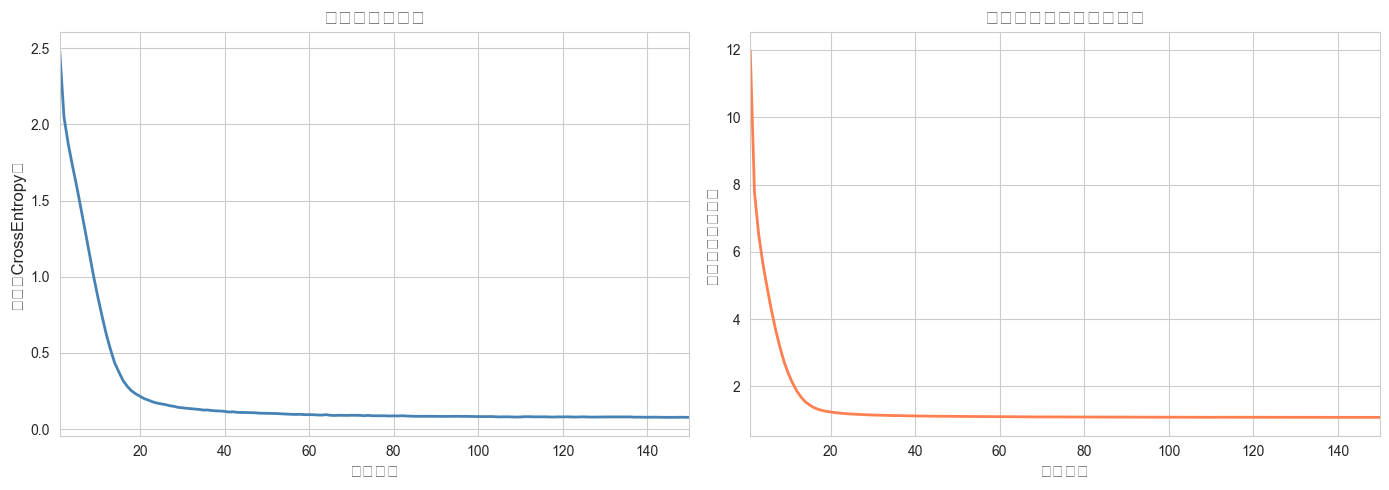

最終損失: 0.0782
最終パープレキシティ: 1.08

【パープレキシティの解釈】
パープレキシティ = exp(損失) で、モデルが次のトークンを予測する際の
「迷い」の程度を表します。値が小さいほど予測が正確です。
語彙サイズ 26 に対してランダム予測のパープレキシティは 26.0 です。


In [16]:
# ============================================================
# 可視化: 損失曲線とパープレキシティ曲線
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 損失曲線 ---
axes[0].plot(range(1, NUM_EPOCHS + 1), train_losses, color='steelblue',
             linewidth=2)
axes[0].set_xlabel('エポック', fontsize=12)
axes[0].set_ylabel('損失（CrossEntropy）', fontsize=12)
axes[0].set_title('訓練損失の推移', fontsize=14)
axes[0].set_xlim(1, NUM_EPOCHS)

# --- パープレキシティ曲線 ---
axes[1].plot(range(1, NUM_EPOCHS + 1), train_perplexities, color='coral',
             linewidth=2)
axes[1].set_xlabel('エポック', fontsize=12)
axes[1].set_ylabel('パープレキシティ', fontsize=12)
axes[1].set_title('パープレキシティの推移', fontsize=14)
axes[1].set_xlim(1, NUM_EPOCHS)

plt.tight_layout()
plt.show()

print(f'最終損失: {train_losses[-1]:.4f}')
print(f'最終パープレキシティ: {train_perplexities[-1]:.2f}')
print()
print('【パープレキシティの解釈】')
print('パープレキシティ = exp(損失) で、モデルが次のトークンを予測する際の')
print('「迷い」の程度を表します。値が小さいほど予測が正確です。')
print(f'語彙サイズ {vocab_size} に対してランダム予測のパープレキシティは {vocab_size:.1f} です。')

---
## 7. テキスト生成（推論）

訓練済みモデルを使って、**自己回帰的**にテキストを生成します。

### Teacher Forcing vs Autoregressive Generation

| | Teacher Forcing（訓練時） | Autoregressive（推論時） |
|---|---|---|
| **入力** | 正解のトークン列 | 自分の予測したトークン |
| **計算** | 全位置を並列に計算 | 1トークンずつ逐次生成 |
| **効率** | 高い（並列化可能） | 低い（逐次的） |
| **問題** | exposure bias | エラーの蓄積 |

In [17]:
# ============================================================
# セクション7: テキスト生成（推論）
# ============================================================

def generate_greedy(model, start_str, length=150):
    """
    Greedy Decoding（貪欲法）による文生成。
    
    各ステップで最も確率の高いトークンを選択する。
    決定論的で常に同じ結果になる。
    """
    model.eval()
    chars_gen = list(start_str)
    input_ids = torch.tensor([char_to_idx[ch] for ch in start_str],
                             dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        for _ in range(length):
            input_cropped = input_ids[:, -config.max_seq_len:]
            logits = model(input_cropped)
            logits = logits[:, -1, :]  # 最後の位置
            # Greedy: argmaxで最高確率のトークンを選択
            next_id = torch.argmax(logits, dim=-1, keepdim=True)
            input_ids = torch.cat([input_ids, next_id], dim=1)
            chars_gen.append(idx_to_char[next_id.item()])
    
    return ''.join(chars_gen)


def generate_with_temperature(model, start_str, length=150, temperature=1.0):
    """
    Temperature Sampling による文生成。
    
    temperature < 1.0: よりシャープな分布 → 保守的な生成
    temperature = 1.0: 元の確率分布
    temperature > 1.0: より平坦な分布 → 多様な生成
    """
    model.eval()
    chars_gen = list(start_str)
    input_ids = torch.tensor([char_to_idx[ch] for ch in start_str],
                             dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        for _ in range(length):
            input_cropped = input_ids[:, -config.max_seq_len:]
            logits = model(input_cropped)
            logits = logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            input_ids = torch.cat([input_ids, next_id], dim=1)
            chars_gen.append(idx_to_char[next_id.item()])
    
    return ''.join(chars_gen)

# ------------------------------------------------------------
# 各手法で生成
# ------------------------------------------------------------
start_text = 'the cat '

print('=' * 70)
print('【Greedy Decoding（貪欲法）】')
print('=' * 70)
greedy_result = generate_greedy(model, start_text, length=120)
print(greedy_result)
print()

print('=' * 70)
print('【Temperature Sampling (T=0.5) — 保守的】')
print('=' * 70)
torch.manual_seed(42)
temp_05 = generate_with_temperature(model, start_text, length=120, temperature=0.5)
print(temp_05)
print()

print('=' * 70)
print('【Temperature Sampling (T=1.0) — 標準】')
print('=' * 70)
torch.manual_seed(42)
temp_10 = generate_with_temperature(model, start_text, length=120, temperature=1.0)
print(temp_10)
print()

print('=' * 70)
print('【Temperature Sampling (T=1.5) — 多様】')
print('=' * 70)
torch.manual_seed(42)
temp_15 = generate_with_temperature(model, start_text, length=120, temperature=1.5)
print(temp_15)

【Greedy Decoding（貪欲法）】
the cat woke up early.
the cat ran to the garden again.
the bird was there waiting for the cat.
they played together all day lon

【Temperature Sampling (T=0.5) — 保守的】
the cat liked to play in the garden.
every day the cat would chase butterflies.
one day the cat found a small bird.
the bird was

【Temperature Sampling (T=1.0) — 標準】
the cat liked to play in the garden.
every day the cat would chase butterflies.
one day the cat found a small bird.
the bird was

【Temperature Sampling (T=1.5) — 多様】
the cat liked to play in the garden.
every day the cat would chase butterflies.
one day the cat found a small bird.
the bird was


C:\Users\yuzup\AppData\Local\Temp\ipykernel_24828\748628953.py:69: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yuzup\AppData\Local\Temp\ipykernel_24828\748628953.py:69: UserWarning: Glyph 35347 (\N{CJK UNIFIED IDEOGRAPH-8A13}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yuzup\AppData\Local\Temp\ipykernel_24828\748628953.py:69: UserWarning: Glyph 32244 (\N{CJK UNIFIED IDEOGRAPH-7DF4}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yuzup\AppData\Local\Temp\ipykernel_24828\748628953.py:69: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yuzup\AppData\Local\Temp\ipykernel_24828\748628953.py:69: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yuzup\AppData\Local\Temp\ipykernel_24828\748628953.py:69: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) miss

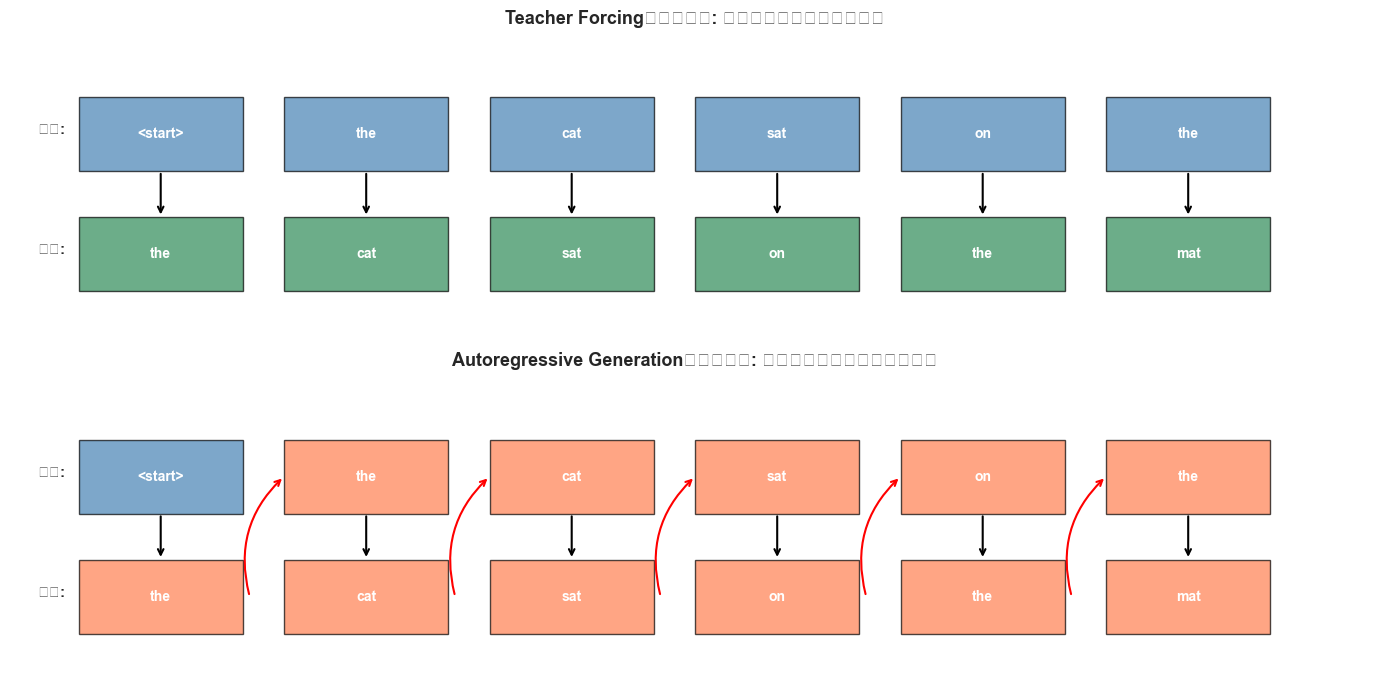

【Teacher Forcing】全位置で正解を入力 → 並列計算が可能
【Autoregressive】 自分の予測を入力に使う → 逐次的に生成

※ Teacher Forcing は訓練効率が良いが、推論時とのギャップ
  (exposure bias) が生じることがある。


In [18]:
# ============================================================
# Teacher Forcing vs Autoregressive の違いの図解
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# --- Teacher Forcing の図 ---
ax = axes[0]
tf_tokens = ['<start>', 'the', 'cat', 'sat', 'on', 'the']
tf_targets = ['the', 'cat', 'sat', 'on', 'the', 'mat']

for i, (tok, tgt) in enumerate(zip(tf_tokens, tf_targets)):
    # 入力トークン（青）
    ax.add_patch(plt.Rectangle((i*1.5, 1.5), 1.2, 0.8,
                 facecolor='steelblue', edgecolor='black', alpha=0.7))
    ax.text(i*1.5 + 0.6, 1.9, tok, ha='center', va='center',
            fontsize=10, color='white', fontweight='bold')
    # ターゲット（緑）
    ax.add_patch(plt.Rectangle((i*1.5, 0.2), 1.2, 0.8,
                 facecolor='seagreen', edgecolor='black', alpha=0.7))
    ax.text(i*1.5 + 0.6, 0.6, tgt, ha='center', va='center',
            fontsize=10, color='white', fontweight='bold')
    # 矢印
    ax.annotate('', xy=(i*1.5 + 0.6, 1.0), xytext=(i*1.5 + 0.6, 1.5),
               arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

ax.set_xlim(-0.5, 9.5)
ax.set_ylim(-0.3, 3.0)
ax.set_title('Teacher Forcing（訓練時）: 正解トークンを入力に使用',
             fontsize=13, fontweight='bold')
ax.text(-0.3, 1.9, '入力:', fontsize=11, fontweight='bold')
ax.text(-0.3, 0.6, '予測:', fontsize=11, fontweight='bold')
ax.axis('off')

# --- Autoregressive の図 ---
ax = axes[1]
ar_tokens = ['<start>', 'the', 'cat', 'sat', 'on', 'the']

for i, tok in enumerate(ar_tokens):
    color = 'steelblue' if i == 0 else 'coral'
    ax.add_patch(plt.Rectangle((i*1.5, 1.5), 1.2, 0.8,
                 facecolor=color, edgecolor='black', alpha=0.7))
    ax.text(i*1.5 + 0.6, 1.9, tok, ha='center', va='center',
            fontsize=10, color='white', fontweight='bold')
    # 予測トークン
    ax.add_patch(plt.Rectangle((i*1.5, 0.2), 1.2, 0.8,
                 facecolor='coral', edgecolor='black', alpha=0.7))
    next_tok = ar_tokens[i+1] if i < len(ar_tokens)-1 else 'mat'
    ax.text(i*1.5 + 0.6, 0.6, next_tok, ha='center', va='center',
            fontsize=10, color='white', fontweight='bold')
    # 縦矢印
    ax.annotate('', xy=(i*1.5 + 0.6, 1.0), xytext=(i*1.5 + 0.6, 1.5),
               arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    # 横矢印（予測→次の入力）
    if i < len(ar_tokens) - 1:
        ax.annotate('', xy=((i+1)*1.5, 1.9),
                   xytext=(i*1.5 + 1.2 + 0.05, 0.6),
                   arrowprops=dict(arrowstyle='->', color='red',
                                  lw=1.5, connectionstyle='arc3,rad=-0.3'))

ax.set_xlim(-0.5, 9.5)
ax.set_ylim(-0.3, 3.0)
ax.set_title('Autoregressive Generation（推論時）: 自分の予測を次の入力に使用',
             fontsize=13, fontweight='bold')
ax.text(-0.3, 1.9, '入力:', fontsize=11, fontweight='bold')
ax.text(-0.3, 0.6, '予測:', fontsize=11, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

print('【Teacher Forcing】全位置で正解を入力 → 並列計算が可能')
print('【Autoregressive】 自分の予測を入力に使う → 逐次的に生成')
print()
print('※ Teacher Forcing は訓練効率が良いが、推論時とのギャップ')
print('  (exposure bias) が生じることがある。')

---
## 8. 学習過程の分析

### 8.1 Attention重みの可視化

モデルがどの文字に注目しているかを、Attention重みから分析します。

C:\Users\yuzup\anaconda3\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\yuzup\anaconda3\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\yuzup\anaconda3\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 29031 (\N{CJK UNIFIED IDEOGRAPH-7167}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\yuzup\anaconda3\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 20808 (\N{CJK UNIFIED IDEOGRAPH-5148}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\yuzup\anaconda3\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\yuzup\anaconda3\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) Arial.
  fig.ca

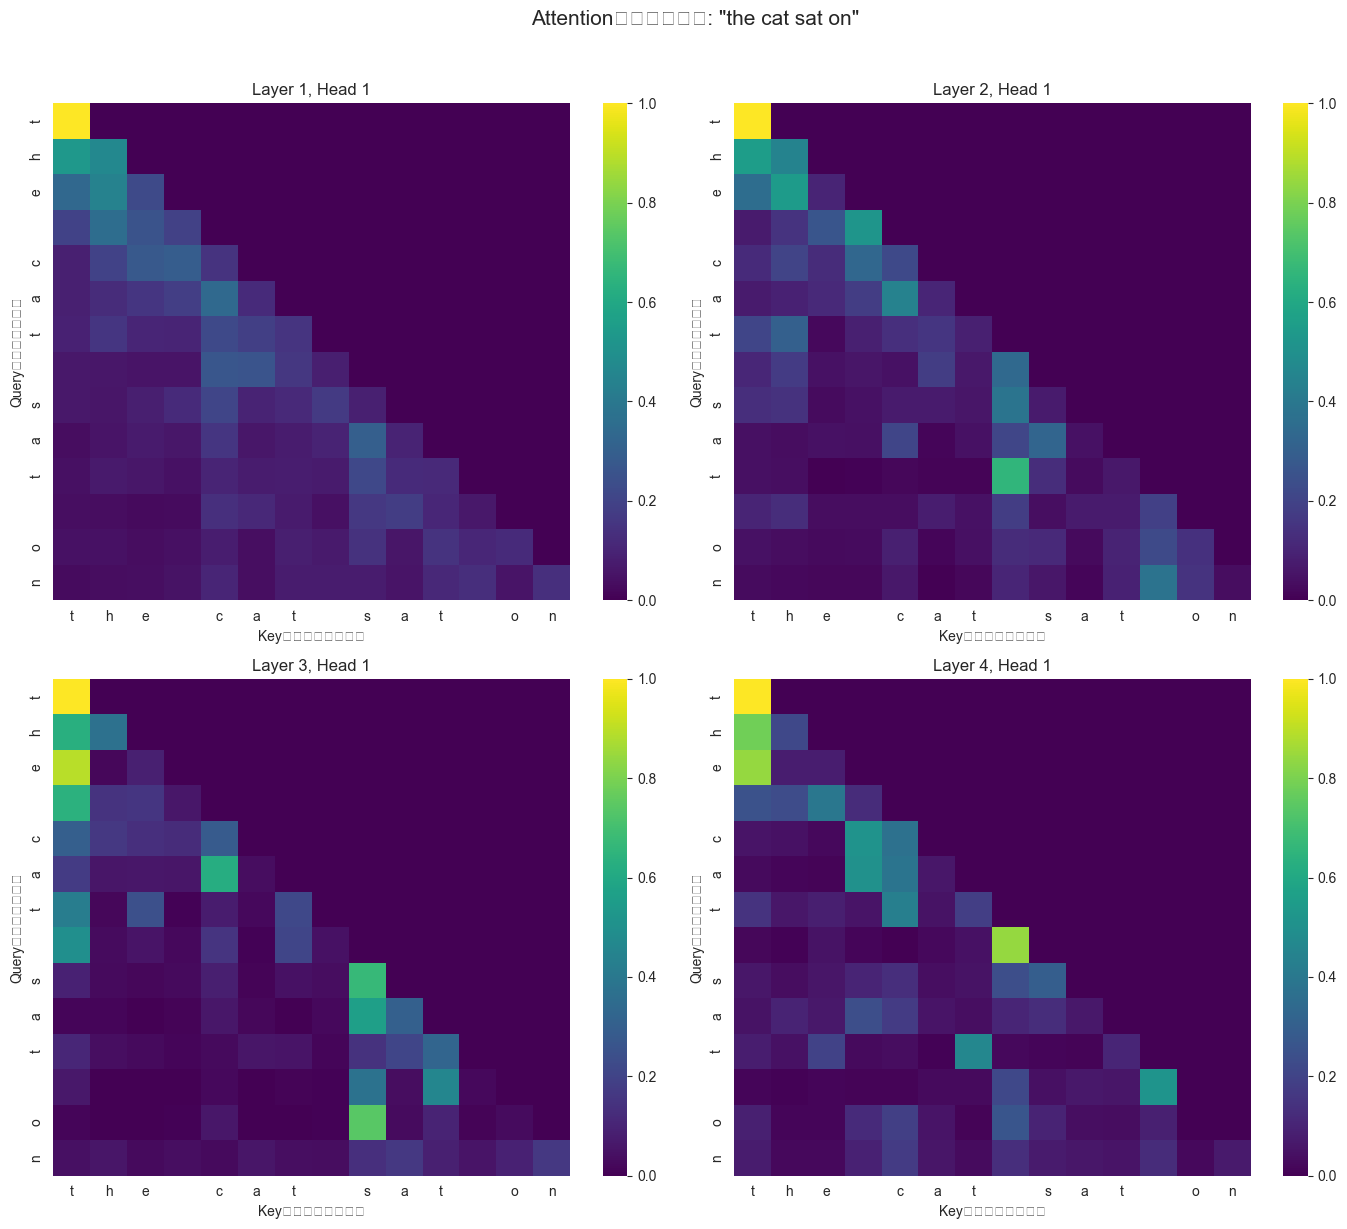

【解説】
各ヒートマップは、Query文字がKey文字にどれだけ注目しているかを示します。
・下三角形のパターン → Causal Maskの効果（未来は見えない）
・層が深くなるにつれて、より抽象的なパターンを学習しています。


In [19]:
# ============================================================
# セクション8: Attention重みの可視化
# ============================================================

def visualize_attention(model, text, layer_idx=0, head_idx=0):
    """
    指定した層・ヘッドのAttention重みをヒートマップで可視化する。
    
    Args:
        model: 訓練済みGPTモデル
        text: 入力テキスト
        layer_idx: 表示するTransformer層のインデックス
        head_idx: 表示するAttentionヘッドのインデックス
    """
    model.eval()
    # テキストをトークン化
    input_ids = torch.tensor([char_to_idx[ch] for ch in text],
                             dtype=torch.long).unsqueeze(0).to(device)
    
    # フォワードパスを実行（Attention重みが保存される）
    with torch.no_grad():
        _ = model(input_ids)
    
    # 指定した層のAttention重みを取得
    attn_weights = model.blocks[layer_idx].attn.attn_weights
    # (1, n_heads, seq_len, seq_len) → (seq_len, seq_len)
    attn = attn_weights[0, head_idx].cpu().numpy()
    
    return attn

# 可視化するテキスト
vis_text = 'the cat sat on'
chars_list = list(vis_text)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for i in range(4):
    ax = axes[i // 2][i % 2]
    attn = visualize_attention(model, vis_text, layer_idx=i, head_idx=0)
    
    sns.heatmap(attn[:len(chars_list), :len(chars_list)],
                ax=ax, cmap='viridis',
                xticklabels=chars_list,
                yticklabels=chars_list,
                vmin=0, vmax=1)
    ax.set_title(f'Layer {i+1}, Head 1', fontsize=12)
    ax.set_xlabel('Key（参照先の文字）')
    ax.set_ylabel('Query（現在の文字）')

plt.suptitle(f'Attention重みの可視化: "{vis_text}"',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print('【解説】')
print('各ヒートマップは、Query文字がKey文字にどれだけ注目しているかを示します。')
print('・下三角形のパターン → Causal Maskの効果（未来は見えない）')
print('・層が深くなるにつれて、より抽象的なパターンを学習しています。')

C:\Users\yuzup\AppData\Local\Temp\ipykernel_24828\978523785.py:26: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yuzup\AppData\Local\Temp\ipykernel_24828\978523785.py:26: UserWarning: Glyph 32066 (\N{CJK UNIFIED IDEOGRAPH-7D42}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yuzup\AppData\Local\Temp\ipykernel_24828\978523785.py:26: UserWarning: Glyph 23652 (\N{CJK UNIFIED IDEOGRAPH-5C64}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yuzup\AppData\Local\Temp\ipykernel_24828\978523785.py:26: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yuzup\AppData\Local\Temp\ipykernel_24828\978523785.py:26: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yuzup\AppData\Local\Temp\ipykernel_24828\978523785.py:26: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from

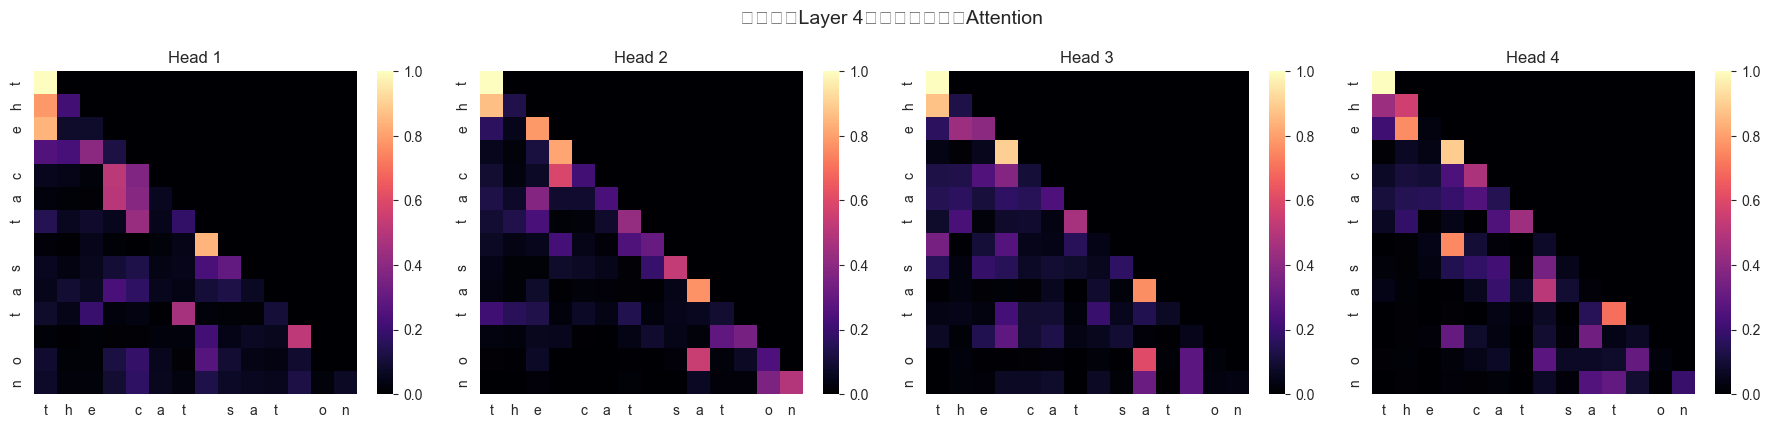

各ヘッドが異なるパターンを学習していることがわかります。
あるヘッドは直前の文字に注目し、別のヘッドはスペースや特定の文字に注目しています。


In [20]:
# ============================================================
# マルチヘッドAttentionの比較
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# 最終層の4つのヘッドを比較
model.eval()
input_ids = torch.tensor([char_to_idx[ch] for ch in vis_text],
                         dtype=torch.long).unsqueeze(0).to(device)

with torch.no_grad():
    _ = model(input_ids)

attn_weights = model.blocks[-1].attn.attn_weights  # 最終層

for h in range(4):
    attn = attn_weights[0, h, :len(chars_list), :len(chars_list)].cpu().numpy()
    sns.heatmap(attn, ax=axes[h], cmap='magma',
                xticklabels=chars_list, yticklabels=chars_list,
                vmin=0, vmax=1, square=True)
    axes[h].set_title(f'Head {h+1}', fontsize=12)

plt.suptitle(f'最終層（Layer {config.n_layers}）の各ヘッドのAttention',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('各ヘッドが異なるパターンを学習していることがわかります。')
print('あるヘッドは直前の文字に注目し、別のヘッドはスペースや特定の文字に注目しています。')

In [21]:
# ============================================================
# エポックごとの生成品質の変化
# ============================================================

print('=' * 70)
print('学習過程での生成品質の変化')
print('=' * 70)

for epoch_num, sample_text in sorted(generation_snapshots.items()):
    print(f'\nEpoch {epoch_num:3d}: "{sample_text[:80]}..."')

print('\n' + '=' * 70)
print('【解説】')
print('初期エポックではランダムな文字列が生成されますが、')
print('学習が進むにつれて、コーパスに含まれる単語やフレーズが')
print('再現されるようになります。')

学習過程での生成品質の変化

Epoch   1: "the cat xthnn.
the
tha anvein at twgen unde  p ket t benenab.
tcamd ..."

Epoch  30: "the cat would chase butterflies.
one day the cat found a small bird...."

Epoch  60: "the cat went home for dinner.
the cat ate fish and drank milk.
after..."

Epoch  90: "the cat listened to the song happily.
then the cat went home for din..."

Epoch 120: "the cat liked to play in the garden.
every day the cat would chase b..."

Epoch 150: "the cat watched the bird carefully.
the bird sang a beautiful song.
..."

【解説】
初期エポックではランダムな文字列が生成されますが、
学習が進むにつれて、コーパスに含まれる単語やフレーズが
再現されるようになります。


---
## 9. BERT vs GPTの比較まとめ

ここまでの内容を踏まえ、BERTとGPTを総合的に比較します。

In [22]:
# ============================================================
# セクション9: BERT vs GPTの比較まとめ
# ============================================================

# 比較表を表示
print('┌─────────────────┬─────────────────────┬─────────────────────┐')
print('│     項目         │   BERT (Encoder)    │   GPT (Decoder)     │')
print('├─────────────────┼─────────────────────┼─────────────────────┤')
print('│ アーキテクチャ    │ Encoder-only        │ Decoder-only        │')
print('│ Attention方向    │ 双方向（Bi-dir）     │ 左→右（Causal）     │')
print('│ 事前学習目的      │ MLM + NSP           │ CLM (next-token)    │')
print('│ マスク           │ ランダムマスク [MASK] │ Causal Mask (下三角) │')
print('│ 主な用途         │ 分類, NER, QA       │ 文章生成, 対話       │')
print('│ 文脈利用         │ 前後の文脈          │ 左側の文脈のみ       │')
print('│ 推論方式         │ 一括処理            │ 自己回帰的（逐次）   │')
print('│ 長所             │ 文脈理解が深い      │ 生成タスクに強い     │')
print('│ 短所             │ 生成が苦手          │ 右側の文脈を使えない │')
print('│ 代表モデル        │ BERT, RoBERTa       │ GPT-2/3/4, LLaMA    │')
print('│ 損失関数         │ CE (マスクされた位置) │ CE (全位置)          │')
print('└─────────────────┴─────────────────────┴─────────────────────┘')
print()
print('【ポイント】')
print('・BERTは「穴埋め問題」、GPTは「続きを書く問題」を解いている')
print('・現在の大規模言語モデル（LLM）はGPTスタイルが主流')
print('・ChatGPT, GPT-4, LLaMA, Gemini 等はすべてDecoder-onlyアーキテクチャ')

┌─────────────────┬─────────────────────┬─────────────────────┐
│     項目         │   BERT (Encoder)    │   GPT (Decoder)     │
├─────────────────┼─────────────────────┼─────────────────────┤
│ アーキテクチャ    │ Encoder-only        │ Decoder-only        │
│ Attention方向    │ 双方向（Bi-dir）     │ 左→右（Causal）     │
│ 事前学習目的      │ MLM + NSP           │ CLM (next-token)    │
│ マスク           │ ランダムマスク [MASK] │ Causal Mask (下三角) │
│ 主な用途         │ 分類, NER, QA       │ 文章生成, 対話       │
│ 文脈利用         │ 前後の文脈          │ 左側の文脈のみ       │
│ 推論方式         │ 一括処理            │ 自己回帰的（逐次）   │
│ 長所             │ 文脈理解が深い      │ 生成タスクに強い     │
│ 短所             │ 生成が苦手          │ 右側の文脈を使えない │
│ 代表モデル        │ BERT, RoBERTa       │ GPT-2/3/4, LLaMA    │
│ 損失関数         │ CE (マスクされた位置) │ CE (全位置)          │
└─────────────────┴─────────────────────┴─────────────────────┘

【ポイント】
・BERTは「穴埋め問題」、GPTは「続きを書く問題」を解いている
・現在の大規模言語モデル（LLM）はGPTスタイルが主流
・ChatGPT, GPT-4, LLaMA, Gemini 等はすべてDecoder-onlyアーキテクチャ


C:\Users\yuzup\anaconda3\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 21452 (\N{CJK UNIFIED IDEOGRAPH-53CC}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\yuzup\anaconda3\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\yuzup\anaconda3\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 21521 (\N{CJK UNIFIED IDEOGRAPH-5411}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\yuzup\anaconda3\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 21452 (\N{CJK UNIFIED IDEOGRAPH-53CC}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\yuzup\anaconda3\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\yuzup\anaconda3\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 21521 (\N{CJK UNIFIED IDEOGRAPH-5411}) missing from font(s) Arial.


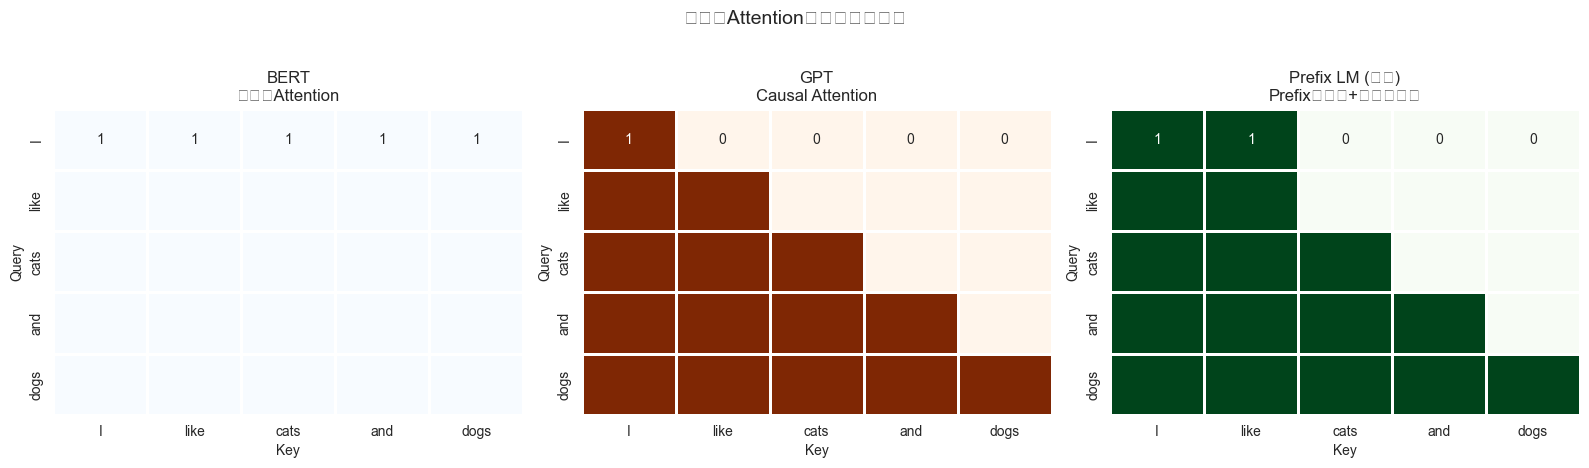

1 = 参照可能, 0 = マスク（参照不可）

Prefix LMは、BERTとGPTの中間的なアプローチで、
入力部分は双方向、生成部分は因果的にするハイブリッドです。


In [23]:
# ============================================================
# BERT vs GPT のAttentionパターン比較図（復習）
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

tokens_ex = ['I', 'like', 'cats', 'and', 'dogs']
n = len(tokens_ex)

# --- BERT: 全結合 ---
bert_attn = np.ones((n, n))
sns.heatmap(bert_attn, ax=axes[0], cmap='Blues', cbar=False,
            xticklabels=tokens_ex, yticklabels=tokens_ex,
            linewidths=1, annot=True, fmt='.0f')
axes[0].set_title('BERT\n双方向Attention', fontsize=12)

# --- GPT: 因果的 ---
gpt_attn = np.tril(np.ones((n, n)))
sns.heatmap(gpt_attn, ax=axes[1], cmap='Oranges', cbar=False,
            xticklabels=tokens_ex, yticklabels=tokens_ex,
            linewidths=1, annot=True, fmt='.0f')
axes[1].set_title('GPT\nCausal Attention', fontsize=12)

# --- Prefix LM (参考) ---
prefix_len = 2
prefix_attn = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if j < prefix_len:  # prefix部分は全員が見える
            prefix_attn[i][j] = 1
        elif i >= prefix_len and j <= i:  # 残りは因果的
            prefix_attn[i][j] = 1
sns.heatmap(prefix_attn, ax=axes[2], cmap='Greens', cbar=False,
            xticklabels=tokens_ex, yticklabels=tokens_ex,
            linewidths=1, annot=True, fmt='.0f')
axes[2].set_title('Prefix LM (参考)\nPrefix双方向+残り因果的', fontsize=12)

for ax in axes:
    ax.set_xlabel('Key')
    ax.set_ylabel('Query')

plt.suptitle('異なるAttentionパターンの比較', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

print('1 = 参照可能, 0 = マスク（参照不可）')
print()
print('Prefix LMは、BERTとGPTの中間的なアプローチで、')
print('入力部分は双方向、生成部分は因果的にするハイブリッドです。')

---
## 10. まとめ・チートシート・よくある間違い

### まとめ

このノートブックでは、GPTスタイルの自己回帰言語モデルを学びました。

1. **Causal Language Modeling (CLM)**: 左から右への条件付き確率の積で言語をモデル化
2. **Causal Mask**: 下三角マスクにより未来の情報を遮断
3. **Decoder-only Transformer**: GPTのアーキテクチャの基本構造
4. **Teacher Forcing**: 訓練時に正解列を入力として使用する効率的な学習法
5. **Autoregressive Generation**: 推論時に自分の予測を入力に使う逐次生成
6. **Temperature Sampling**: 生成の多様性を制御するパラメータ

In [24]:
# ============================================================
# セクション10: チートシート
# ============================================================

print('╔══════════════════════════════════════════════════════════════╗')
print('║         CLM vs MLM 比較チートシート                         ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║                                                            ║')
print('║  【CLM (Causal Language Modeling) — GPTスタイル】           ║')
print('║  ・目的: P(wₜ|w₁,...,wₜ₋₁) を最大化                       ║')
print('║  ・マスク: Causal Mask（下三角行列）                        ║')
print('║  ・損失: 全位置のCross-Entropy                              ║')
print('║  ・長所: 自然な文生成が可能                                 ║')
print('║  ・短所: 右側の文脈を利用できない                           ║')
print('║                                                            ║')
print('║  【MLM (Masked Language Modeling) — BERTスタイル】          ║')
print('║  ・目的: P(w_mask|w_context) を最大化                       ║')
print('║  ・マスク: ランダムに15%をマスク                            ║')
print('║  ・損失: マスク位置のみのCross-Entropy                      ║')
print('║  ・長所: 双方向の文脈を活用できる                           ║')
print('║  ・短所: 生成タスクには不向き                               ║')
print('║                                                            ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  【Temperature Samplingガイド】                             ║')
print('║  ・T < 1.0: シャープ（保守的、繰り返しが多い）              ║')
print('║  ・T = 1.0: 元の分布（バランス）                            ║')
print('║  ・T > 1.0: 平坦（多様だがノイジー）                        ║')
print('║  ・T → 0  : Greedy Decodingに近づく                         ║')
print('║  ・T → ∞  : 一様分布（完全ランダム）に近づく                ║')
print('║                                                            ║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║         CLM vs MLM 比較チートシート                         ║
╠══════════════════════════════════════════════════════════════╣
║                                                            ║
║  【CLM (Causal Language Modeling) — GPTスタイル】           ║
║  ・目的: P(wₜ|w₁,...,wₜ₋₁) を最大化                       ║
║  ・マスク: Causal Mask（下三角行列）                        ║
║  ・損失: 全位置のCross-Entropy                              ║
║  ・長所: 自然な文生成が可能                                 ║
║  ・短所: 右側の文脈を利用できない                           ║
║                                                            ║
║  【MLM (Masked Language Modeling) — BERTスタイル】          ║
║  ・目的: P(w_mask|w_context) を最大化                       ║
║  ・マスク: ランダムに15%をマスク                            ║
║  ・損失: マスク位置のみのCross-Entropy                      ║
║  ・長所: 双方向の文脈を活用できる                           ║
║  ・短所: 生成タスクには不向き                               ║
║                                            

In [25]:
# ============================================================
# よくある間違い
# ============================================================

print('=' * 60)
print('よくある間違い Top 3')
print('=' * 60)
print()
print('❌ 間違い1: Causal Maskを適用し忘れる')
print('  → マスクなしだと各トークンが未来の情報を見れてしまい、')
print('    訓練時の損失は下がるが、推論時に文が崩壊する。')
print('  ✅ 対策: 必ず上三角を -inf でマスクする。')
print()
print('❌ 間違い2: Teacher Forcingの入出力のずれを間違える')
print('  → 入力: [w₁, w₂, ..., w_{T-1}]')
print('    ターゲット: [w₂, w₃, ..., w_T]')
print('  ✅ 対策: 入力とターゲットは必ず1トークンずらす。')
print()
print('❌ 間違い3: Temperatureの効果を勘違いする')
print('  → T<1で多様に、T>1で保守的になると思いがち。')
print('  ✅ 対策: T<1 = シャープ（保守的）, T>1 = 平坦（多様）。')
print('    logitsをTで割ることで分布の鋭さを調整している。')

よくある間違い Top 3

❌ 間違い1: Causal Maskを適用し忘れる
  → マスクなしだと各トークンが未来の情報を見れてしまい、
    訓練時の損失は下がるが、推論時に文が崩壊する。
  ✅ 対策: 必ず上三角を -inf でマスクする。

❌ 間違い2: Teacher Forcingの入出力のずれを間違える
  → 入力: [w₁, w₂, ..., w_{T-1}]
    ターゲット: [w₂, w₃, ..., w_T]
  ✅ 対策: 入力とターゲットは必ず1トークンずらす。

❌ 間違い3: Temperatureの効果を勘違いする
  → T<1で多様に、T>1で保守的になると思いがち。
  ✅ 対策: T<1 = シャープ（保守的）, T>1 = 平坦（多様）。
    logitsをTで割ることで分布の鋭さを調整している。


---
## 11. 自己評価クイズ

以下のクイズで理解度を確認しましょう。各質問をクリックすると回答が表示されます。

In [26]:
# ============================================================
# セクション11: 自己評価クイズ
# ============================================================

quizzes = [
    {
        'q': 'Q1: GPTの目的関数（CLM）を数式で書いてください。BERTのMLMとどう違いますか？',
        'a': ('CLMの目的関数: L = -(1/T) Σ log P(wₜ | w₁,...,wₜ₋₁; θ)\n'
              '全位置で次のトークンを予測する。\n'
              'MLMとの違い:\n'
              '・CLM: 全位置で損失を計算、左側のコンテキストのみ使用\n'
              '・MLM: マスクされた位置のみで損失を計算、双方向のコンテキストを使用')
    },
    {
        'q': 'Q2: Causal Maskはなぜ必要ですか？マスクなしで訓練するとどうなりますか？',
        'a': ('Causal Maskは未来のトークンへのAttentionを防ぐために必要。\n'
              'マスクなしで訓練すると:\n'
              '・訓練時: 「答え」が見えるので損失は非常に低くなる\n'
              '・推論時: 未来の情報がないため、訓練時との乖離が大きくなり、\n'
              '  生成品質が著しく低下する（情報リーク問題）')
    },
    {
        'q': 'Q3: Teacher Forcingとは何ですか？そのメリットとデメリットは？',
        'a': ('Teacher Forcing: 訓練時に正解のトークン列を入力として与える手法。\n'
              'メリット:\n'
              '・全位置を並列に計算できるため、訓練が高速\n'
              '・安定した勾配が得られる\n'
              'デメリット:\n'
              '・Exposure Bias: 訓練時は常に正解を見るが、推論時は自分の\n'
              '  （誤りを含む可能性のある）予測を入力に使うため、ギャップが生じる')
    },
    {
        'q': 'Q4: Temperature=0.1とTemperature=2.0ではどちらがより多様なテキストを生成しますか？理由は？',
        'a': ('Temperature=2.0の方がより多様なテキストを生成する。\n'
              '理由: logitsをTで割るため:\n'
              '・T=0.1: logitsが10倍に拡大 → softmax後の分布が非常にシャープ\n'
              '  → ほぼGreedy Decodingと同じ（最高確率のトークンが選ばれる）\n'
              '・T=2.0: logitsが半分に縮小 → softmax後の分布が平坦\n'
              '  → 低確率のトークンも選ばれやすくなる → 多様な生成')
    },
    {
        'q': 'Q5: GPTが現代のLLM（ChatGPT, LLaMA等）の主流アーキテクチャとなった理由を2つ挙げてください。',
        'a': ('1. スケーラビリティ: Decoder-onlyアーキテクチャはシンプルで、\n'
              '   パラメータ数の増加に対して性能が予測可能にスケールする\n'
              '   （Scaling Laws）。\n'
              '2. 汎用性: next-token predictionという単純なタスクで事前学習\n'
              '   するだけで、Few-shot/Zero-shotで多様なタスクに対応できる。\n'
              '   特別なタスクヘッドを追加する必要がない。\n'
              '補足: KVキャッシュによる効率的な推論が可能な点も重要。')
    },
]

for quiz in quizzes:
    print('━' * 60)
    print(quiz['q'])
    print()
    print('【回答】（以下をスクロールして確認）')
    print()
    print(quiz['a'])
    print()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Q1: GPTの目的関数（CLM）を数式で書いてください。BERTのMLMとどう違いますか？

【回答】（以下をスクロールして確認）

CLMの目的関数: L = -(1/T) Σ log P(wₜ | w₁,...,wₜ₋₁; θ)
全位置で次のトークンを予測する。
MLMとの違い:
・CLM: 全位置で損失を計算、左側のコンテキストのみ使用
・MLM: マスクされた位置のみで損失を計算、双方向のコンテキストを使用

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Q2: Causal Maskはなぜ必要ですか？マスクなしで訓練するとどうなりますか？

【回答】（以下をスクロールして確認）

Causal Maskは未来のトークンへのAttentionを防ぐために必要。
マスクなしで訓練すると:
・訓練時: 「答え」が見えるので損失は非常に低くなる
・推論時: 未来の情報がないため、訓練時との乖離が大きくなり、
  生成品質が著しく低下する（情報リーク問題）

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Q3: Teacher Forcingとは何ですか？そのメリットとデメリットは？

【回答】（以下をスクロールして確認）

Teacher Forcing: 訓練時に正解のトークン列を入力として与える手法。
メリット:
・全位置を並列に計算できるため、訓練が高速
・安定した勾配が得られる
デメリット:
・Exposure Bias: 訓練時は常に正解を見るが、推論時は自分の
  （誤りを含む可能性のある）予測を入力に使うため、ギャップが生じる

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Q4: Temperature=0.1とTemperature=2.0ではどちらがより多様なテキストを生成しますか？理由は？

【回答】（以下をスクロールして確認）

Temperature=2.0の方がより多様なテキストを生成する。

---

## 学習目標の振り返り

- [x] Causal Language Modeling (CLM) 目的関数の数理を理解できる
- [x] ミニGPTをスクラッチ実装できる（Decoder-only Transformer）
- [x] next-token predictionの訓練ループを構築できる
- [x] Teacher Forcing と Autoregressive Generation の違いを説明できる
- [x] 小規模テキストデータで文章生成を実行できる
- [x] Attention重みの可視化から言語モデルの振る舞いを分析できる

### 次のステップ

- Notebook 165 以降: より大規模なモデルやデータでの実験
- Top-k / Top-p (Nucleus) Sampling の実装
- KVキャッシュによる推論高速化
- LoRA / QLoRA によるファインチューニング